# Controlled Benchmark for Telecom Customer Churn Prediction

Companion notebook to the manuscript *Performance Evaluation of Machine Learning and Gradient
Boosting Models for Explainable Customer Churn Prediction*.

This notebook implements the full protocol described in Section 3 of the revised manuscript:

1. Leakage free preprocessing fitted inside each training fold
2. One-hot encoding of nominal attributes, with a label encoding arm for sensitivity analysis
3. Imbalance ablation across no treatment, class weights, SMOTE and ADASYN
4. Five times repeated stratified five fold cross-validation with nested hyperparameter tuning
5. Accuracy, precision, recall, F1, ROC-AUC, PR-AUC and Brier score
6. Decision threshold selected on the training fold by maximising F1
7. Paired Wilcoxon tests with Holm correction, plus a confirmatory holdout
8. SHAP and LIME with measured fidelity, stability and rank agreement

Every value reported in Section 4 of the manuscript is written to CSV by this notebook.
Nothing is transcribed by hand.

**Run order:** execute the cells in sequence. Set `QUICK = True` in the configuration cell for a
fast smoke test before committing to the full run.

## 1. Configuration

In [1]:
# --------------------------------------------------------------------------- #
# Configuration. Edit these values only.
# --------------------------------------------------------------------------- #
DATA_PATH = "telecom_customer_churn.csv"   # path to the Maven Analytics churn file
OUT_DIR   = "results"                      # all CSV outputs are written here
SEED      = 42

N_SPLITS  = 5     # outer folds
N_REPEATS = 5     # repetitions of the outer cross-validation
N_ITER    = 12    # randomised search iterations per model per fold
QUICK     = False # True: 1 repetition, no tuning. Use for a smoke test.

TREATMENTS = ["none", "weights", "smote", "adasyn"]
FINAL_TREATMENT = "adasyn"   # treatment used for the confirmatory holdout and explainability

DROP_COLS = [
    "Customer ID", "Churn Category", "Churn Reason",
    "City", "Zip Code", "Latitude", "Longitude",
]
TARGET_RAW = "Customer Status"

### Note on the dropped columns

`Churn Category` and `Churn Reason` are populated only for customers who churned and are therefore
direct target leaks. `Customer ID` is an identifier. `City`, `Zip Code`, `Latitude` and `Longitude`
are high cardinality location fields that encode operator coverage rather than customer behaviour.
Their removal is a substantive modelling decision, not housekeeping, and is documented in
Section 3.2.1 of the manuscript.

## 2. Environment and imports

In [2]:
# Install only if the environment is missing packages.
# %pip install -q pandas numpy scikit-learn imbalanced-learn xgboost lightgbm shap lime scipy

In [3]:
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, wilcoxon

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV, RepeatedStratifiedKFold, StratifiedKFold, train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore")
os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED)

# Record library versions for the reproducibility appendix.
import sklearn, imblearn, scipy
versions = {
    "python": __import__("sys").version.split()[0],
    "numpy": np.__version__, "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__, "imbalanced-learn": imblearn.__version__,
    "xgboost": xgb.__version__, "lightgbm": lgb.__version__, "scipy": scipy.__version__,
}
pd.Series(versions).to_csv(os.path.join(OUT_DIR, "environment_versions.csv"))
versions

{'python': '3.13.5',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'scikit-learn': '1.6.1',
 'imbalanced-learn': '0.13.0',
 'xgboost': '3.2.0',
 'lightgbm': '4.6.0',
 'scipy': '1.15.3'}

## 3. Data loading and target construction

In [4]:
def load_data(path):
    df = pd.read_csv(r"C:\Users\USER\OneDrive - Durban University of Technology\Documents\practice dataset\thesis code\telecom_customer_churn.csv")
    if TARGET_RAW not in df.columns:
        raise ValueError(f"Expected column '{TARGET_RAW}' in {path}")
    y = (df[TARGET_RAW].astype(str).str.strip().str.lower() == "churned").astype(int)
    X = df.drop(columns=[c for c in DROP_COLS + [TARGET_RAW] if c in df.columns])
    return X, y


X, y = load_data(DATA_PATH)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"Rows: {len(X)}")
print(f"Predictors retained: {X.shape[1]}  ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"Churn rate: {y.mean():.4f}   Imbalance ratio 1:{(1 - y.mean()) / y.mean():.2f}")

Rows: 7043
Predictors retained: 30  (12 numeric, 18 categorical)
Churn rate: 0.2654   Imbalance ratio 1:2.77


The predictor counts printed above fill the highlighted placeholders in Section 3.2.1 of the
manuscript. The churn rate and imbalance ratio should match the values quoted in Sections 3.1
and 4.1.1.

In [5]:
# Missing value audit for Section 3.2.2
missing = (X.isna().mean() * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False).to_frame("percent_missing")
missing.to_csv(os.path.join(OUT_DIR, "missing_value_audit.csv"))
missing

,percent_missing
Offer,55.05
Avg Monthly GB Download,21.67
Internet Type,21.67
Online Backup,21.67
Online Security,21.67
Streaming TV,21.67
Streaming Movies,21.67
Device Protection Plan,21.67
Premium Tech Support,21.67
Streaming Music,21.67


## 4. Preprocessing pipeline

Preprocessing is constructed as a `ColumnTransformer` and is always fitted inside the training
fold. Imputation statistics, encoder categories and scaling parameters are therefore estimated on
training data alone. Scaling is applied only for the learners that are sensitive to feature
magnitude, since tree based models are invariant to monotone rescaling.

In [6]:
def build_preprocessor(X, encoding="onehot", scale=True):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scale", StandardScaler()))

    if encoding == "onehot":
        cat_enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        cat_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    cat_steps = [("impute", SimpleImputer(strategy="most_frequent")), ("encode", cat_enc)]

    return ColumnTransformer([
        ("num", SkPipeline(num_steps), num_cols),
        ("cat", SkPipeline(cat_steps), cat_cols),
    ])

## 5. Models and search spaces

Nine classifiers spanning linear, probabilistic, instance based, kernel based, bagging and boosting
paradigms. The third element of each tuple indicates whether the learner requires feature scaling.
The search spaces reproduce Table 3 of the manuscript.

In [7]:
def model_zoo(class_weight=None):
    cw = "balanced" if class_weight == "balanced" else None
    return {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, random_state=SEED, class_weight=cw),
            {"clf__C": [0.01, 0.1, 1, 10]}, True),
        "Decision Tree": (
            DecisionTreeClassifier(random_state=SEED, class_weight=cw),
            {"clf__max_depth": [4, 6, 8, 10, 12],
             "clf__min_samples_split": [2, 5, 10, 20]}, False),
        "Gaussian Naive Bayes": (
            GaussianNB(),
            {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}, True),
        "K-Nearest Neighbours": (
            KNeighborsClassifier(),
            {"clf__n_neighbors": [3, 5, 7, 9, 11],
             "clf__weights": ["uniform", "distance"]}, True),
        "Support Vector Machine": (
            SVC(probability=True, random_state=SEED, class_weight=cw),
            {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.01, 0.1]}, True),
        "Random Forest": (
            RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight=cw),
            {"clf__n_estimators": [200, 400], "clf__max_depth": [6, 10, None],
             "clf__max_features": ["sqrt", 0.5]}, False),
        "Gradient Boosting": (
            GradientBoostingClassifier(random_state=SEED),
            {"clf__n_estimators": [100, 200, 300],
             "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
             "clf__max_depth": [3, 4, 5]}, False),
        "XGBoost": (
            xgb.XGBClassifier(random_state=SEED, eval_metric="logloss",
                              n_jobs=-1, tree_method="hist"),
            {"clf__n_estimators": [100, 200, 300],
             "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
             "clf__max_depth": [3, 4, 6], "clf__subsample": [0.8, 1.0]}, False),
        "LightGBM": (
            lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
            {"clf__n_estimators": [100, 200, 300],
             "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
             "clf__num_leaves": [15, 31, 63]}, False),
    }


def make_pipeline(X, estimator, treatment, encoding, scale):
    steps = [("pre", build_preprocessor(X, encoding=encoding, scale=scale))]
    if treatment == "smote":
        steps.append(("res", SMOTE(random_state=SEED)))
    elif treatment == "adasyn":
        steps.append(("res", ADASYN(random_state=SEED)))
    steps.append(("clf", estimator))
    return ImbPipeline(steps)

The resampler sits **inside** the imbalanced-learn pipeline, between preprocessing and the
classifier. This matters: `imblearn.Pipeline` applies resampling during `fit` only and skips it
during `predict`, so no synthetic sample can reach a validation or test partition. This is the
mechanism that makes the leakage claim in Section 3.2.5 verifiable rather than aspirational.

## 6. Metrics and threshold selection

In [8]:
def best_f1_threshold(y_true, proba):
    grid = np.linspace(0.05, 0.95, 91)
    scores = [f1_score(y_true, (proba >= t).astype(int), zero_division=0) for t in grid]
    return float(grid[int(np.argmax(scores))])


def score_all(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall":    recall_score(y_true, pred, zero_division=0),
        "f1":        f1_score(y_true, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, proba),
        "pr_auc":    average_precision_score(y_true, proba),
        "brier":     brier_score_loss(y_true, proba),
        "threshold": threshold,
    }

The threshold is chosen on the training fold, never on the data used for scoring. Training on
resampled data shifts the predicted probability distribution upward for the minority class, so the
default value of 0.5 no longer corresponds to a meaningful operating point. The PR-AUC baseline
for a random classifier equals the positive class prevalence, which is roughly 0.265 here, and
reported values should be read against that reference.

## 7. Cross-validated benchmark

In [9]:
def run_benchmark(X, y, treatment, encoding, n_splits=N_SPLITS, n_repeats=N_REPEATS,
                  tune=True, n_iter=N_ITER, verbose=True):
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=SEED)
    zoo = model_zoo(class_weight="balanced" if treatment == "weights" else None)
    rows, fold_scores, chosen = [], {}, {}

    for name, (est, grid, needs_scale) in zoo.items():
        t0 = time.time()
        fold_scores[name], chosen[name] = [], []

        for fold_id, (tr, va) in enumerate(cv.split(X, y)):
            X_tr, X_va = X.iloc[tr], X.iloc[va]
            y_tr, y_va = y.iloc[tr], y.iloc[va]

            assert len(set(tr) & set(va)) == 0, "train and validation indices overlap"

            pipe = make_pipeline(X, clone(est), treatment, encoding, needs_scale)

            if tune and grid:
                inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
                n = min(n_iter, int(np.prod([len(v) for v in grid.values()])))
                search = RandomizedSearchCV(pipe, grid, n_iter=n, scoring="f1",
                                            cv=inner, random_state=SEED, n_jobs=-1, refit=True)
                search.fit(X_tr, y_tr)
                fitted = search.best_estimator_
                chosen[name].append(json.dumps(search.best_params_))
            else:
                pipe.fit(X_tr, y_tr)
                fitted = pipe

            thr = best_f1_threshold(y_tr, fitted.predict_proba(X_tr)[:, 1])
            m = score_all(y_va, fitted.predict_proba(X_va)[:, 1], thr)
            m.update({"model": name, "fold": fold_id,
                      "treatment": treatment, "encoding": encoding})
            rows.append(m)
            fold_scores[name].append(m["f1"])

        if verbose:
            print(f"  {name:<24} F1 = {np.mean(fold_scores[name]):.4f} "
                  f"(SD {np.std(fold_scores[name]):.4f})  [{time.time() - t0:.0f}s]")

    df = pd.DataFrame(rows)
    summary = (df.groupby("model")[["accuracy", "precision", "recall", "f1",
                                    "roc_auc", "pr_auc", "brier", "threshold"]]
                 .agg(["mean", "std"]).round(4))
    modal = {k: (pd.Series(v).mode().iloc[0] if v else None) for k, v in chosen.items()}
    return df, summary, fold_scores, modal

The complete benchmark is repeated under four imbalance treatments. Without the untreated control
condition, no claim about the value of ADASYN can be sustained. If the treatments turn out to be
statistically indistinguishable, that is the finding and it should be reported as such.

In [10]:
REPEATS = 1 if QUICK else N_REPEATS
TUNE = not QUICK

X_dev, X_hold, y_dev, y_hold = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"Development set: {len(X_dev)}   Confirmatory holdout: {len(X_hold)}")

Development set: 5634   Confirmatory holdout: 1409


## 9. Model performance comparison (Table 5)

In [12]:
table5 = pd.read_csv(os.path.join(OUT_DIR, f"summary_{FINAL_TREATMENT}.csv"),
                     header=[0, 1], index_col=0)
table5.to_csv(os.path.join(OUT_DIR, "table5_model_performance.csv"))
table5

accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
model                                                                       
Decision Tree            0.7892  0.0130    0.5815  0.0225  0.7429  0.0411   
Gaussian Naive Bayes     0.7927  0.0135    0.5812  0.0218  0.7893  0.0248   
Gradient Boosting        0.8384  0.0131    0.6803  0.0372  0.7469  0.0392   
K-Nearest Neighbours     0.5770  0.1236    0.4051  0.0972  0.8882  0.1654   
LightGBM                 0.8430  0.0109    0.6827  0.0245  0.7659  0.0375   
Logistic Regression      0.8325  0.0123    0.6642  0.0252  0.7489  0.0307   
Random Forest            0.8282  0.0124    0.6579  0.0236  0.7361  0.0319   
Support Vector Machine   0.8257  0.0101    0.6586  0.0207  0.7155  0.0442   
XGBoost                  0.8405  0.0114    0.6828  0.0287  0.7493  0.0357   

                            f1         roc_auc          pr_auc          \
                          mean     std    mean     std    mean     std   
model                                                                    
Decision Tree           0.6515  0.0190  0.8477  0.0129  0.6069  0.0278   
Gaussian Naive Bayes    0.6691  0.0169  0.8644  0.0117  0.6800  0.0251   
Gradient Boosting       0.7105  0.0167  0.9068  0.0102  0.7863  0.0233   
K-Nearest Neighbours    0.5346  0.0421  0.8246  0.0212  0.5708  0.0407   
LightGBM                0.7212  0.0193  0.9094  0.0101  0.7916  0.0232   
Logistic Regression     0.7035  0.0198  0.8958  0.0108  0.7509  0.0316   
Random Forest           0.6944  0.0223  0.8915  0.0120  0.7461  0.0292   
Support Vector Machine  0.6850  0.0225  0.8876  0.0114  0.7246  0.0336   
XGBoost                 0.7136  0.0189  0.9063  0.0098  0.7855  0.0224   

                         brier         threshold          
                          mean     std      mean     std  
model                                                     
Decision Tree           0.1472  0.0075    0.3940  0.0504  
Gaussian Naive Bayes    0.2108  0.0133    0.9040  0.0809  
Gradient Boosting       0.1080  0.0062    0.4584  0.0305  
K-Nearest Neighbours    0.2178  0.0090    0.2096  0.2905  
LightGBM                0.1054  0.0059    0.4168  0.0264  
Logistic Regression     0.1436  0.0067    0.6888  0.0209  
Random Forest           0.1178  0.0069    0.4720  0.0243  
Support Vector Machine  0.1340  0.0074    0.6520  0.0299  
XGBoost                 0.1084  0.0059    0.4624  0.0412

In [13]:
# Selected hyperparameters for Table 3
table3 = pd.Series(modal_store[FINAL_TREATMENT], name="modal_selected_configuration")
table3.to_csv(os.path.join(OUT_DIR, "table3_selected_hyperparameters.csv"))
table3

Logistic Regression                                          {"clf__C": 10}
Decision Tree             {"clf__min_samples_split": 2, "clf__max_depth"...
Gaussian Naive Bayes                          {"clf__var_smoothing": 1e-09}
K-Nearest Neighbours      {"clf__weights": "distance", "clf__n_neighbors...
Support Vector Machine                   {"clf__gamma": 0.01, "clf__C": 10}
Random Forest             {"clf__n_estimators": 200, "clf__max_features"...
Gradient Boosting         {"clf__n_estimators": 100, "clf__max_depth": 4...
XGBoost                   {"clf__subsample": 1.0, "clf__n_estimators": 1...
LightGBM                  {"clf__num_leaves": 15, "clf__n_estimators": 1...
Name: modal_selected_configuration, dtype: object

## 10. Paired statistical comparison (Table 6)

All models share the same fold partitions, so comparisons are paired. Differences in fold level F1
are tested with the Wilcoxon signed rank test and corrected for multiplicity using the Holm
procedure. An effect size accompanies each test, because with twenty five paired observations a
detectable difference is not necessarily a meaningful one.

The benchmark is repeated with ordinal label encoding of nominal attributes. Label encoding imposes
an arbitrary distance and ordering on unordered categories, which tree ensembles largely absorb but
linear and distance based learners cannot. The expectation is that the base learners improve under
one-hot encoding while the ensembles are broadly unaffected, narrowing the gap between the two
families. This quantifies how much of the apparent ensemble advantage is a preprocessing artefact.

## 12. Confirmatory holdout, operating points and calibration (Table 8)

The holdout was set aside before any modelling decision was made and is scored exactly once. Three
operating points are reported, because the choice of threshold is a managerial decision about
retention budget rather than a modelling one.

In [17]:
est, grid, needs_scale = model_zoo()[best_model_name]
final_model = make_pipeline(X_dev, clone(est), FINAL_TREATMENT, "onehot", needs_scale)
final_model.fit(X_dev, y_dev)

proba_dev = final_model.predict_proba(X_dev)[:, 1]
proba_hold = final_model.predict_proba(X_hold)[:, 1]
thr_f1 = best_f1_threshold(y_dev, proba_dev)
thr_decile = float(np.quantile(proba_hold, 0.90))

rows = []
for label, thr in [("Default", 0.5), ("F1 maximising", thr_f1), ("Top decile budget", thr_decile)]:
    m = score_all(y_hold, proba_hold, thr)
    m["operating_point"] = label
    m["customers_contacted"] = int((proba_hold >= thr).sum())
    rows.append(m)

table8 = pd.DataFrame(rows).set_index("operating_point").round(4)
table8.to_csv(os.path.join(OUT_DIR, "table8_operating_points.csv"))
table8

,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,threshold,customers_contacted
operating_point,,,,,,,,,
Default,0.8346,0.6986,0.6631,0.6804,0.8994,0.7565,0.1119,0.5000,355
F1 maximising,0.8339,0.6892,0.6818,0.6855,0.8994,0.7565,0.1119,0.4800,370
Top decile budget,0.8048,0.8511,0.3209,0.4660,0.8994,0.7565,0.1119,0.8465,141


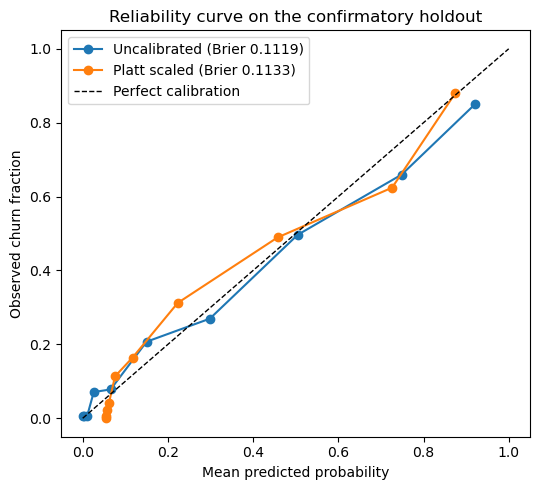

In [18]:
# Calibration: reliability curve and Brier score before and after Platt scaling (Figure 9)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

calibrated = CalibratedClassifierCV(final_model, method="sigmoid", cv=3)
calibrated.fit(X_dev, y_dev)
proba_cal = calibrated.predict_proba(X_hold)[:, 1]

fig, ax = plt.subplots(figsize=(5.5, 5))
for proba, label in [(proba_hold, "Uncalibrated"), (proba_cal, "Platt scaled")]:
    frac, mean_pred = calibration_curve(y_hold, proba, n_bins=10, strategy="quantile")
    b = brier_score_loss(y_hold, proba)
    ax.plot(mean_pred, frac, marker="o", label=f"{label} (Brier {b:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn fraction")
ax.set_title("Reliability curve on the confirmatory holdout")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figure9_calibration.png"), dpi=300)
plt.show()

pd.DataFrame([{
    "brier_uncalibrated": brier_score_loss(y_hold, proba_hold),
    "brier_calibrated": brier_score_loss(y_hold, proba_cal),
}]).round(4).to_csv(os.path.join(OUT_DIR, "calibration_brier.csv"), index=False)

## 13. Global attribution with SHAP (Table 9, Figures 10 to 13)

In [19]:
import shap

pre = final_model.named_steps["pre"]
clf = final_model.named_steps["clf"]
feat_names = list(pre.get_feature_names_out())
Xtr_t = pre.transform(X_dev)
Xte_t = pre.transform(X_hold)

explainer = shap.TreeExplainer(clf)
sample = Xte_t[: min(500, len(Xte_t))]
sv = explainer.shap_values(sample)
if isinstance(sv, list):
    sv = sv[1]

table9 = (pd.DataFrame({"feature": feat_names, "mean_abs_shap": np.abs(sv).mean(axis=0)})
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True))
table9.head(10).round(4).to_csv(os.path.join(OUT_DIR, "table9_shap_global.csv"), index=False)
table9.head(10).round(4)

,feature,mean_abs_shap
0,cat__Contract_Month-to-Month,1.2517
1,num__Number of Referrals,1.0273
2,num__Number of Dependents,0.6801
3,num__Monthly Charge,0.3424
4,cat__Contract_Two Year,0.3260
5,num__Tenure in Months,0.2560
6,cat__Paperless Billing_No,0.2492
7,cat__Payment Method_Credit Card,0.1959
8,num__Age,0.1940
9,cat__Streaming Music_No,0.1490


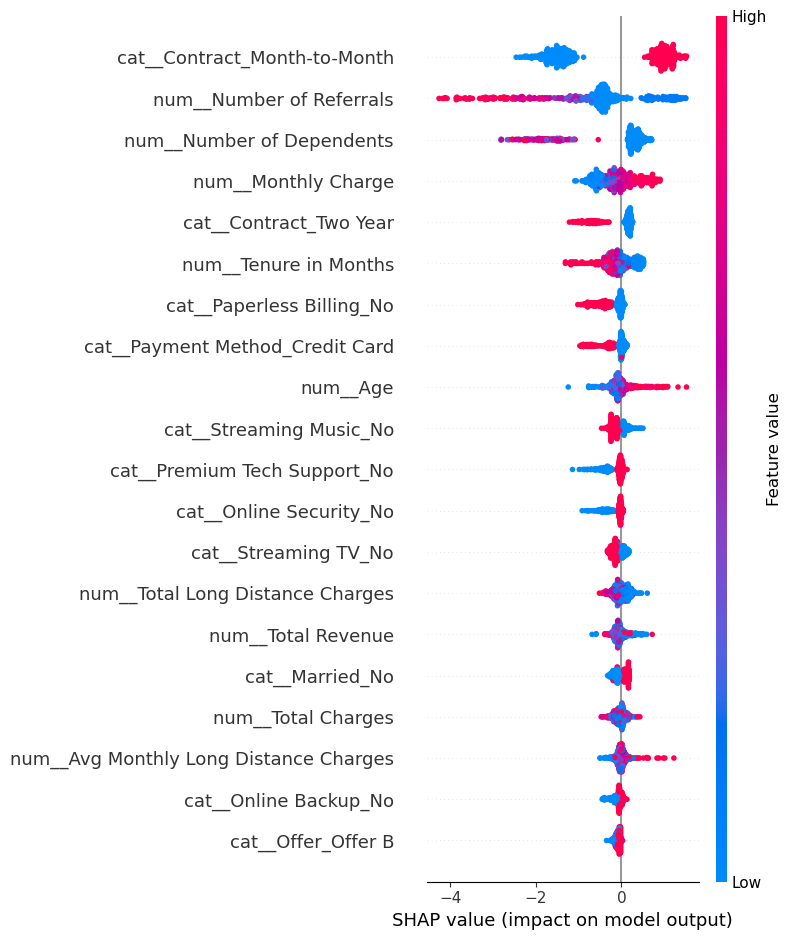

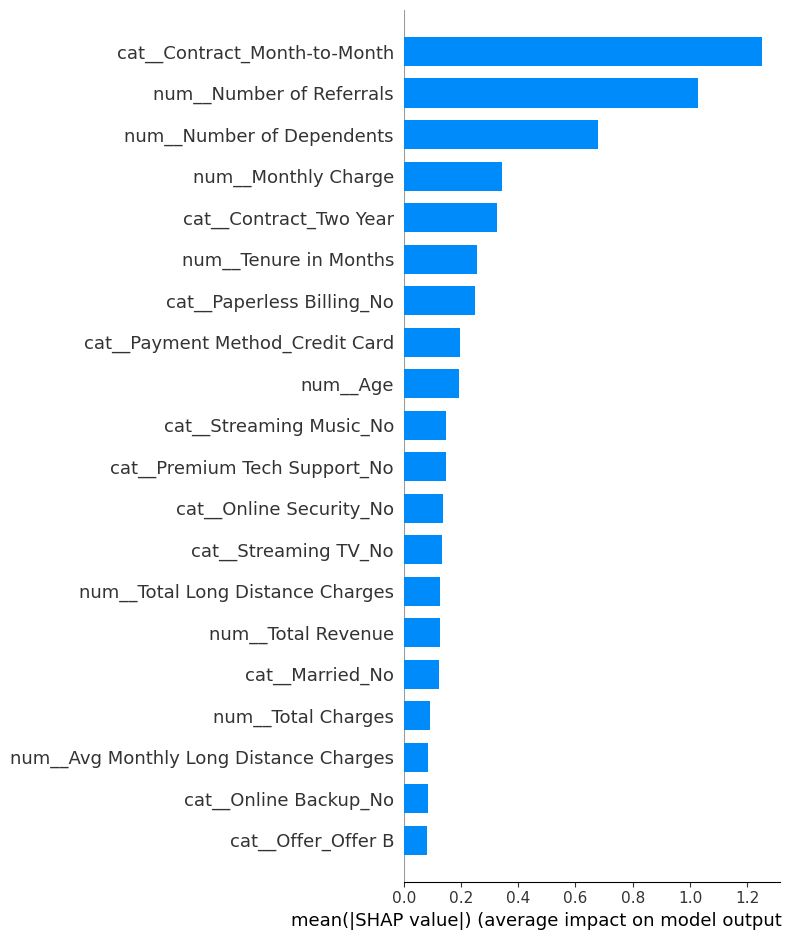

In [20]:
# Figure 10: beeswarm summary
shap.summary_plot(sv, sample, feature_names=feat_names, show=False)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure10_shap_beeswarm.png"), dpi=300)
plt.show()

# Figure 11: ranked importance
shap.summary_plot(sv, sample, feature_names=feat_names, plot_type="bar", show=False)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure11_shap_importance.png"), dpi=300)
plt.show()

True positives available: 255   False negatives available: 119


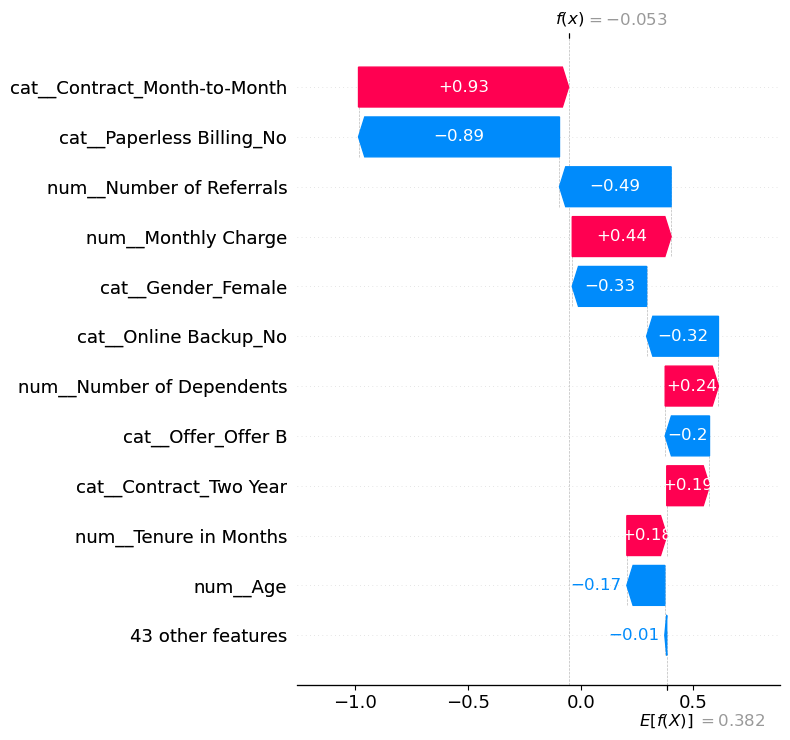

In [21]:
# Figure 12: waterfall for a correctly classified churner
pred_hold = (proba_hold >= thr_f1).astype(int)
tp_idx = np.where((pred_hold == 1) & (y_hold.values == 1))[0]
fn_idx = np.where((pred_hold == 0) & (y_hold.values == 1))[0]
print(f"True positives available: {len(tp_idx)}   False negatives available: {len(fn_idx)}")

i = int(tp_idx[0])
base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) \
             else explainer.expected_value
sv_i = explainer.shap_values(Xte_t[i:i+1])
if isinstance(sv_i, list):
    sv_i = sv_i[1]
shap.plots._waterfall.waterfall_legacy(
    base_value, np.asarray(sv_i).ravel(), feature_names=feat_names, max_display=12, show=False
)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure12_shap_waterfall.png"), dpi=300)
plt.show()

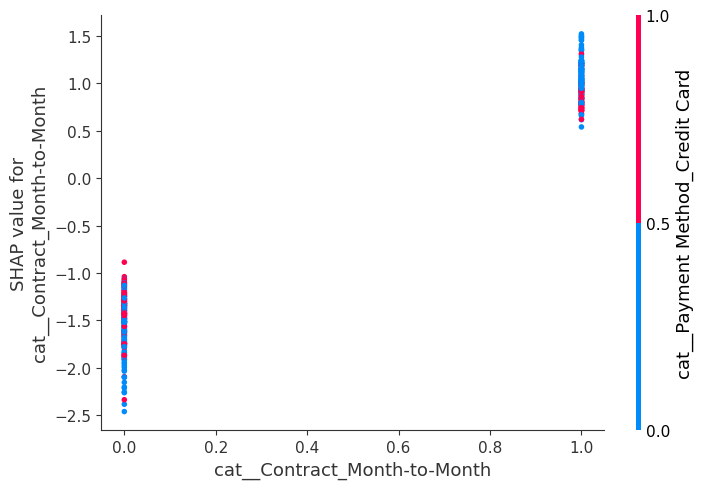

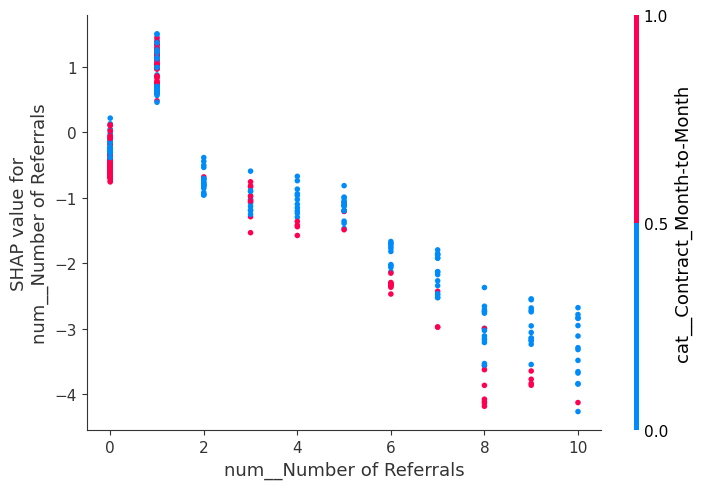

In [22]:
# Figure 13: dependence plots for the two highest ranked features
for rank, feature in enumerate(table9["feature"].head(2), start=1):
    shap.dependence_plot(feature, sv, sample, feature_names=feat_names, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"figure13_shap_dependence_{rank}.png"), dpi=300)
    plt.show()

## 14. Case level attribution with LIME (Figures 14 and 15)

Local fidelity (surrogate R2): 0.4071


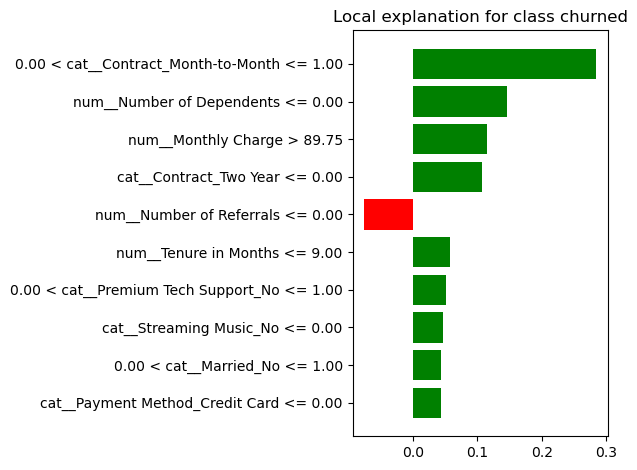

In [24]:
from lime.lime_tabular import LimeTabularExplainer

lime_exp = LimeTabularExplainer(
    Xtr_t, feature_names=feat_names, class_names=["retained", "churned"],
    discretize_continuous=True, random_state=SEED, mode="classification",
)
predict_fn = clf.predict_proba

# Figure 14: correctly classified churner
e_tp = lime_exp.explain_instance(Xte_t[int(tp_idx[0])], predict_fn, num_features=10)
pd.DataFrame(e_tp.as_list(), columns=["feature_condition", "weight"]).round(4).to_csv(
    os.path.join(OUT_DIR, "figure14_lime_true_positive.csv"), index=False)
print(f"Local fidelity (surrogate R2): {e_tp.score:.4f}")
e_tp.as_pyplot_figure()
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure14_lime_true_positive.png"), dpi=300)
plt.show()

Local fidelity (surrogate R2): 0.3927


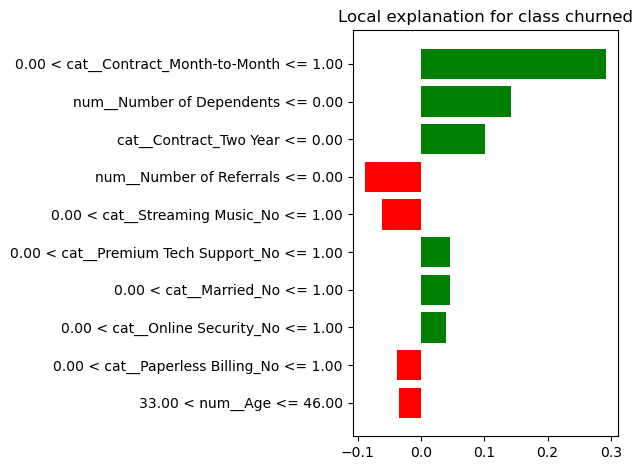

In [25]:
# Figure 15: misclassified churner (false negative)
e_fn = lime_exp.explain_instance(Xte_t[int(fn_idx[0])], predict_fn, num_features=10)
pd.DataFrame(e_fn.as_list(), columns=["feature_condition", "weight"]).round(4).to_csv(
    os.path.join(OUT_DIR, "figure15_lime_false_negative.csv"), index=False)
print(f"Local fidelity (surrogate R2): {e_fn.score:.4f}")
e_fn.as_pyplot_figure()
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure15_lime_false_negative.png"), dpi=300)
plt.show()

Report the weights from the two CSV files above verbatim in Section 4.8, together with the printed
fidelity scores. These are LIME surrogate weights and must not be described as Shapley values.

## 15. Explanation quality (Table 10)

Explanations offered as a basis for customer facing intervention need evidence of their
reliability. Three properties are measured: local fidelity of the surrogate, stability of the
explanation under repeated sampling, and rank agreement between SHAP and LIME.

Low stability would mean a practitioner acting on one explanation could reasonably have received
different guidance from a repeat run of the same procedure, which qualifies the operational
recommendations in Section 5.

In [26]:
N_INSTANCES, N_SEEDS = 200, 10
rng = np.random.RandomState(SEED)
idx = rng.choice(len(Xte_t), min(N_INSTANCES, len(Xte_t)), replace=False)

fidelity, agreement = [], []
for i in idx:
    e = lime_exp.explain_instance(Xte_t[i], predict_fn, num_features=10)
    fidelity.append(e.score)

    lime_vec = np.zeros(len(feat_names))
    for fi, w in dict(e.as_map()[1]).items():
        lime_vec[fi] = w
    s = explainer.shap_values(Xte_t[i:i+1])
    if isinstance(s, list):
        s = s[1]
    rho, _ = spearmanr(np.abs(lime_vec), np.abs(np.asarray(s).ravel()))
    if not np.isnan(rho):
        agreement.append(rho)

print(f"Fidelity computed on {len(fidelity)} instances")

Fidelity computed on 200 instances


In [27]:
jaccard, rankcorr = [], []
for i in idx[:20]:
    tops, weights = [], []
    for s in range(N_SEEDS):
        ex = LimeTabularExplainer(
            Xtr_t, feature_names=feat_names, class_names=["retained", "churned"],
            discretize_continuous=True, random_state=SEED + s, mode="classification",
        )
        e = ex.explain_instance(Xte_t[i], predict_fn, num_features=10)
        m = dict(e.as_map()[1])
        tops.append(set(sorted(m, key=lambda k: -abs(m[k]))[:5]))
        v = np.zeros(len(feat_names))
        for fi, w in m.items():
            v[fi] = w
        weights.append(v)

    jaccard += [len(a & b) / len(a | b)
                for ai, a in enumerate(tops) for b in tops[ai + 1:]]
    rankcorr += [r for r in (spearmanr(weights[a], weights[b]).correlation
                             for a in range(len(weights))
                             for b in range(a + 1, len(weights))) if not np.isnan(r)]

table10 = pd.DataFrame([
    {"property": "Local fidelity (surrogate R2)", "mean": np.mean(fidelity), "sd": np.std(fidelity)},
    {"property": "Stability (top-5 Jaccard)", "mean": np.mean(jaccard), "sd": np.std(jaccard)},
    {"property": "Stability (weight rank correlation)", "mean": np.mean(rankcorr), "sd": np.std(rankcorr)},
    {"property": "SHAP-LIME agreement (Spearman)", "mean": np.mean(agreement), "sd": np.std(agreement)},
]).round(4)
table10.to_csv(os.path.join(OUT_DIR, "table10_explanation_quality.csv"), index=False)
table10

,property,mean,sd
0,Local fidelity (surrogate R2),0.4410,0.0546
1,Stability (top-5 Jaccard),0.9567,0.1121
2,Stability (weight rank correlation),0.8851,0.0689
3,SHAP-LIME agreement (Spearman),0.5245,0.0624


## 17. Output manifest

Every highlighted placeholder in Section 4 of the manuscript maps to one of the files listed below.
Copy the values across directly rather than retyping them, and remove the yellow highlighting as
each cell is filled.

In [30]:
# =========================================================================== #
# Missing figures: 2, 3, 4, 5, 6, 7 and 8
# Paste as a single cell after Section 12 of the notebook, or run as a script.
# Reuses objects already in memory where they exist and falls back to disk
# otherwise, so it works whether or not the kernel still holds the full run.
# =========================================================================== #
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [31]:
RAW_PATH = r"C:\Users\USER\OneDrive - Durban University of Technology\Documents\practice dataset\thesis code\telecom_customer_churn.csv"
OUT_DIR = globals().get("OUT_DIR", "results")
FINAL_TREATMENT = globals().get("FINAL_TREATMENT", "adasyn")
os.makedirs(OUT_DIR, exist_ok=True)

mpl.rcParams.update({"font.size": 9, "axes.grid": True, "grid.linewidth": 0.4,
                     "grid.alpha": 0.5, "axes.axisbelow": True})
BLUE, GREY, GOLD, RED = "#3f6f9f", "#9fb3c8", "#c9a227", "#b03030"

raw = pd.read_csv(RAW_PATH)
raw["churn"] = (raw["Customer Status"].astype(str).str.strip().str.lower() == "churned").astype(int)
prevalence = raw["churn"].mean()

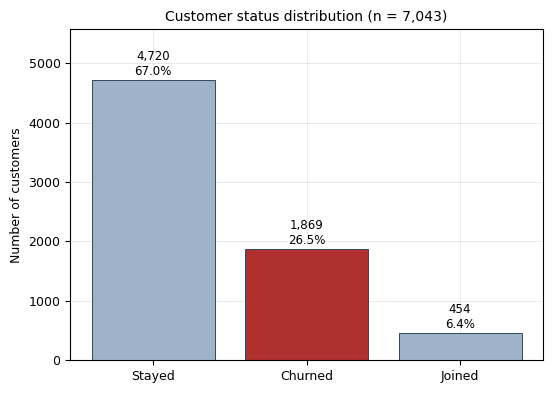

In [32]:
# --------------------------------------------------------------------------- #
# Figure 2. Customer status distribution
# --------------------------------------------------------------------------- #
counts = raw["Customer Status"].value_counts()
fig, ax = plt.subplots(figsize=(5.6, 4.0))
bars = ax.bar(counts.index, counts.values,
              color=[RED if s.lower() == "churned" else GREY for s in counts.index],
              edgecolor="#33475b", linewidth=0.7)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + len(raw) * 0.012,
            f"{v:,}\n{v / len(raw) * 100:.1f}%", ha="center", fontsize=8.5)
ax.set_ylabel("Number of customers")
ax.set_ylim(0, counts.max() * 1.18)
ax.set_title(f"Customer status distribution (n = {len(raw):,})", fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figure2_customer_status.png"), dpi=300, bbox_inches="tight")
plt.show()


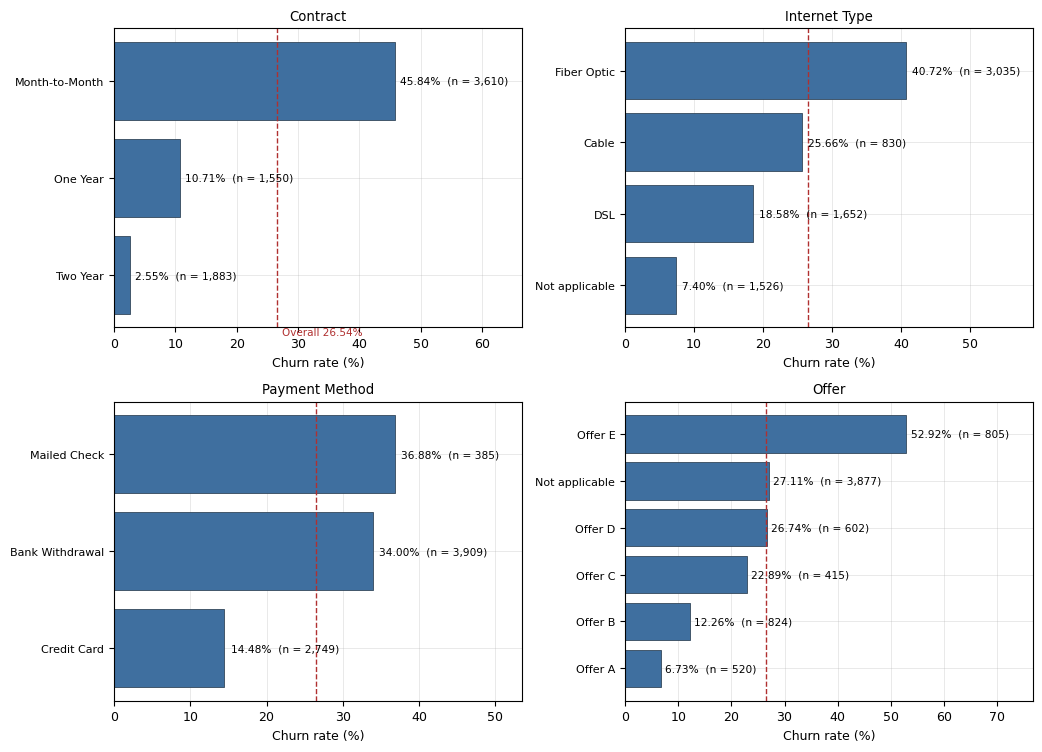

Churn rates written to figure3_churn_rates.csv. Use these to replace the carried-over percentages in Section 4.1.2.


In [33]:
# --------------------------------------------------------------------------- #
# Figure 3. Churn rate by categorical attribute
# --------------------------------------------------------------------------- #
cat_vars = ["Contract", "Internet Type", "Payment Method", "Offer"]
cat_vars = [c for c in cat_vars if c in raw.columns]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.6))
rows_out = []
for ax, col in zip(axes.ravel(), cat_vars):
    g = raw.groupby(col, dropna=False)["churn"].agg(["mean", "size"]).sort_values("mean")
    labels = [("Not applicable" if pd.isna(i) else str(i)) for i in g.index]
    bars = ax.barh(range(len(g)), g["mean"].values * 100,
                   color=BLUE, edgecolor="#33475b", linewidth=0.6)
    for k, (m, n) in enumerate(zip(g["mean"].values, g["size"].values)):
        ax.text(m * 100 + 0.8, k, f"{m * 100:.2f}%  (n = {n:,})", va="center", fontsize=7.6)
        rows_out.append({"attribute": col, "level": labels[k],
                         "churn_rate_pct": round(m * 100, 2), "n": int(n)})
    ax.axvline(prevalence * 100, color=RED, linestyle="--", linewidth=1.0)
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlim(0, min(100, g["mean"].max() * 100 * 1.45))
    ax.set_xlabel("Churn rate (%)")
    ax.set_title(col, fontsize=9.5)

axes.ravel()[0].text(prevalence * 100 + 0.8, -0.62, f"Overall {prevalence * 100:.2f}%",
                     color=RED, fontsize=7.5)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figure3_categorical_churn.png"), dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame(rows_out).to_csv(os.path.join(OUT_DIR, "figure3_churn_rates.csv"), index=False)
print("Churn rates written to figure3_churn_rates.csv. Use these to replace the "
      "carried-over percentages in Section 4.1.2.")


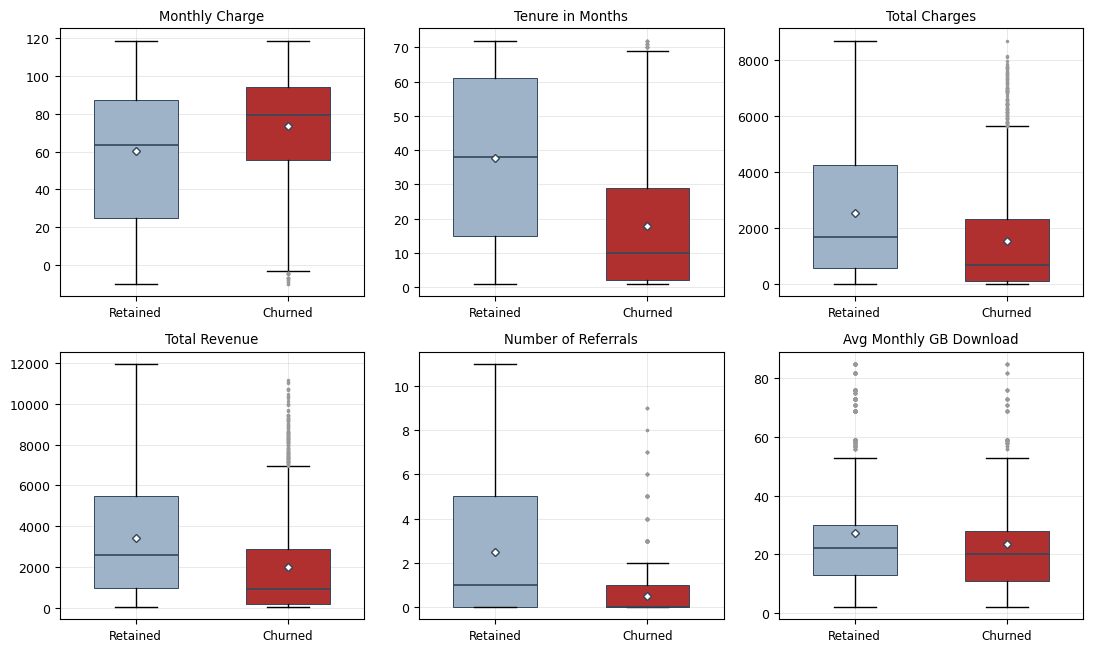

In [34]:
# --------------------------------------------------------------------------- #
# Figure 4. Numeric attribute distributions by churn status
# --------------------------------------------------------------------------- #
num_vars = [c for c in ["Monthly Charge", "Tenure in Months", "Total Charges",
                        "Total Revenue", "Number of Referrals", "Avg Monthly GB Download"]
            if c in raw.columns]

fig, axes = plt.subplots(2, 3, figsize=(11, 6.6))
for ax, col in zip(axes.ravel(), num_vars):
    groups = [raw.loc[raw["churn"] == 0, col].dropna(), raw.loc[raw["churn"] == 1, col].dropna()]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.55, showmeans=True,
                    medianprops={"color": "#33475b", "linewidth": 1.2},
                    meanprops={"marker": "D", "markerfacecolor": "white",
                               "markeredgecolor": "#33475b", "markersize": 4},
                    flierprops={"marker": "o", "markersize": 2.5,
                                "markerfacecolor": "#999", "markeredgecolor": "none"})
    for patch, colour in zip(bp["boxes"], [GREY, RED]):
        patch.set_facecolor(colour)
        patch.set_edgecolor("#33475b")
        patch.set_linewidth(0.7)
    ax.set_xticklabels(["Retained", "Churned"], fontsize=8.5)
    ax.set_title(col, fontsize=9.5)

for ax in axes.ravel()[len(num_vars):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figure4_numeric_boxplots.png"), dpi=300, bbox_inches="tight")
plt.show()

raw.groupby("churn")[num_vars].agg(["median", "mean"]).round(2).to_csv(
    os.path.join(OUT_DIR, "figure4_numeric_summary.csv"))



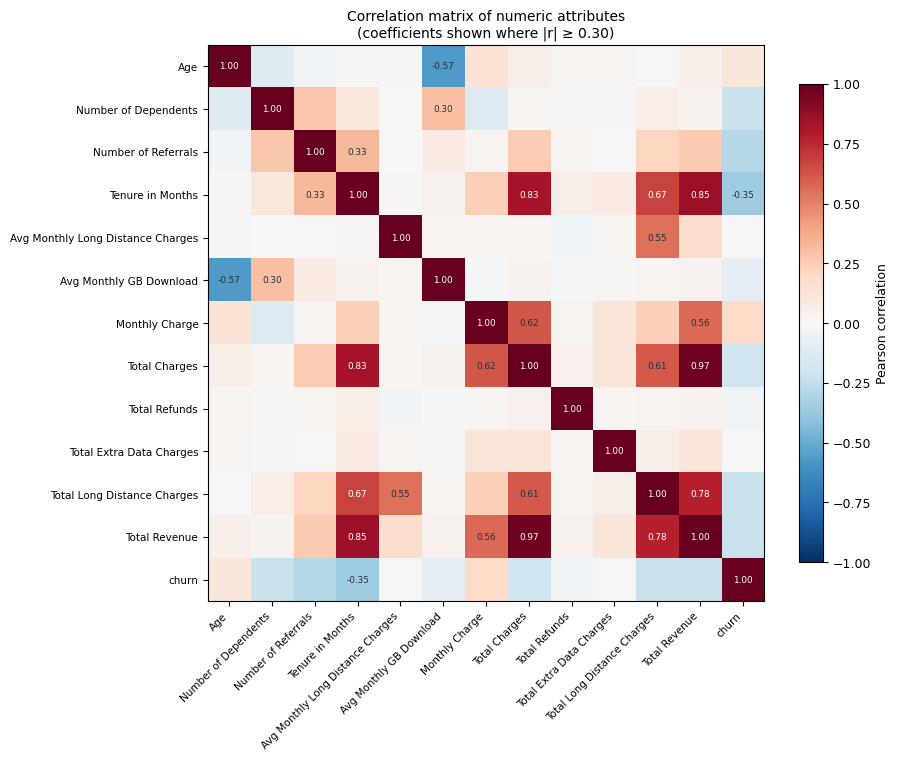

In [35]:
# --------------------------------------------------------------------------- #
# Figure 5. Correlation matrix
# --------------------------------------------------------------------------- #
drop_geo = ["Zip Code", "Latitude", "Longitude"]
corr_cols = [c for c in raw.select_dtypes(include=[np.number]).columns
             if c not in drop_geo and c != "churn"]
corr = raw[corr_cols + ["churn"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9.2, 7.8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.grid(False)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7.5)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=7.5)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.30:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.4,
                    color="white" if abs(v) > 0.65 else "#22303c")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Correlation matrix of numeric attributes\n(coefficients shown where |r| ≥ 0.30)",
             fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figure5_correlation.png"), dpi=300, bbox_inches="tight")
plt.show()

corr.round(3).to_csv(os.path.join(OUT_DIR, "figure5_correlation_matrix.csv"))



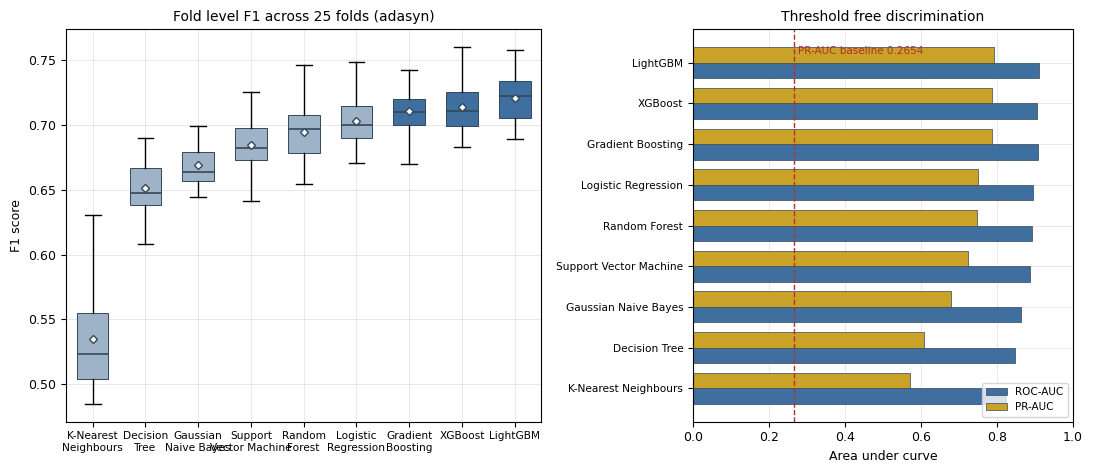

In [36]:
# --------------------------------------------------------------------------- #
# Figure 6. Fold level F1 distribution and threshold free discrimination
# --------------------------------------------------------------------------- #
try:
    folds_df = pd.DataFrame([{"model": m, "f1": v}
                             for m, vals in fold_store[FINAL_TREATMENT].items() for v in vals])
except (NameError, KeyError):
    folds_df = pd.read_csv(os.path.join(OUT_DIR, f"folds_{FINAL_TREATMENT}.csv"))

summary_sel = pd.read_csv(os.path.join(OUT_DIR, f"summary_{FINAL_TREATMENT}.csv"),
                          header=[0, 1], index_col=0)
order = folds_df.groupby("model")["f1"].mean().sort_values().index.tolist()
boosting = {"Gradient Boosting", "XGBoost", "LightGBM"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
bp = ax.boxplot([folds_df.loc[folds_df["model"] == m, "f1"].values for m in order],
                patch_artist=True, widths=0.6, showmeans=True,
                medianprops={"color": "#33475b", "linewidth": 1.2},
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "#33475b", "markersize": 4},
                flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#888",
                            "markeredgecolor": "none"})
for patch, name in zip(bp["boxes"], order):
    patch.set_facecolor(BLUE if name in boosting else GREY)
    patch.set_edgecolor("#33475b")
    patch.set_linewidth(0.7)
ax.set_xticklabels([m.replace(" ", "\n", 1) for m in order], fontsize=7.6)
ax.set_ylabel("F1 score")
ax.set_title(f"Fold level F1 across {folds_df.groupby('model').size().iloc[0]} folds "
             f"({FINAL_TREATMENT})", fontsize=10)

ax = axes[1]
ypos = np.arange(len(order))
w = 0.38
ax.barh(ypos - w / 2, summary_sel[("roc_auc", "mean")].reindex(order).values, height=w,
        color=BLUE, edgecolor="#33475b", linewidth=0.5, label="ROC-AUC")
ax.barh(ypos + w / 2, summary_sel[("pr_auc", "mean")].reindex(order).values, height=w,
        color=GOLD, edgecolor="#33475b", linewidth=0.5, label="PR-AUC")
ax.axvline(prevalence, color=RED, linestyle="--", linewidth=1.0)
ax.text(prevalence + 0.01, len(order) - 0.6, f"PR-AUC baseline {prevalence:.4f}",
        color=RED, fontsize=7.5, va="top")
ax.set_yticks(ypos)
ax.set_yticklabels(order, fontsize=7.6)
ax.set_xlim(0, 1.0)
ax.set_xlabel("Area under curve")
ax.set_title("Threshold free discrimination", fontsize=10)
ax.legend(fontsize=7.5, loc="lower right")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figure6_model_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()


In [37]:
# --------------------------------------------------------------------------- #
# Refit each classifier once and score the holdout (needed for Figures 7 and 8)
# --------------------------------------------------------------------------- #
import time
from sklearn.base import clone
from sklearn.metrics import (confusion_matrix, precision_recall_curve, roc_curve)

holdout_proba, holdout_thr, rows = {}, {}, []
for name, (est_i, _, scale_i) in model_zoo(
        class_weight="balanced" if FINAL_TREATMENT == "weights" else None).items():
    t0 = time.time()
    pipe_i = make_pipeline(X_dev, clone(est_i), FINAL_TREATMENT, "onehot", scale_i)
    pipe_i.fit(X_dev, y_dev)
    thr_i = best_f1_threshold(y_dev, pipe_i.predict_proba(X_dev)[:, 1])
    p_i = pipe_i.predict_proba(X_hold)[:, 1]
    holdout_proba[name], holdout_thr[name] = p_i, thr_i
    m = score_all(y_hold, p_i, thr_i)
    m["model"] = name
    rows.append(m)
    print(f"  {name:<24} holdout F1 = {m['f1']:.4f}  (threshold {thr_i:.3f})  "
          f"[{time.time() - t0:.0f}s]")

holdout_table = pd.DataFrame(rows).set_index("model").round(4)
holdout_table.to_csv(os.path.join(OUT_DIR, "holdout_all_models.csv"))
pd.DataFrame(holdout_proba).assign(y_true=y_hold.values).to_csv(
    os.path.join(OUT_DIR, "holdout_probabilities.csv"), index=False)
order_desc = holdout_table["f1"].sort_values(ascending=False).index.tolist()
display(holdout_table)

  Logistic Regression      holdout F1 = 0.6575  (threshold 0.700)  [1s]
  Decision Tree            holdout F1 = 0.5677  (threshold 0.050)  [1s]
  Gaussian Naive Bayes     holdout F1 = 0.6667  (threshold 0.940)  [1s]
  K-Nearest Neighbours     holdout F1 = 0.4921  (threshold 0.810)  [1s]
  Support Vector Machine   holdout F1 = 0.6598  (threshold 0.660)  [37s]
  Random Forest            holdout F1 = 0.6710  (threshold 0.450)  [2s]
  Gradient Boosting        holdout F1 = 0.7157  (threshold 0.430)  [7s]
  XGBoost                  holdout F1 = 0.6731  (threshold 0.500)  [2s]
  LightGBM                 holdout F1 = 0.6855  (threshold 0.480)  [2s]


,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,threshold
model,,,,,,,,
Logistic Regression,0.8055,0.6174,0.7032,0.6575,0.8871,0.7278,0.1521,0.70
Decision Tree,0.7665,0.5581,0.5775,0.5677,0.7062,0.4345,0.2335,0.05
Gaussian Naive Bayes,0.7913,0.5787,0.7861,0.6667,0.8521,0.6654,0.2235,0.94
K-Nearest Neighbours,0.7729,0.6055,0.4144,0.4921,0.7961,0.5155,0.2252,0.81
Support Vector Machine,0.8112,0.6324,0.6898,0.6598,0.8823,0.7044,0.1376,0.66
Random Forest,0.8204,0.6532,0.6898,0.6710,0.8885,0.7298,0.1180,0.45
Gradient Boosting,0.8353,0.6606,0.7807,0.7157,0.9019,0.7741,0.1105,0.43
XGBoost,0.8318,0.6952,0.6524,0.6731,0.8933,0.7409,0.1197,0.50
LightGBM,0.8339,0.6892,0.6818,0.6855,0.8994,0.7565,0.1119,0.48


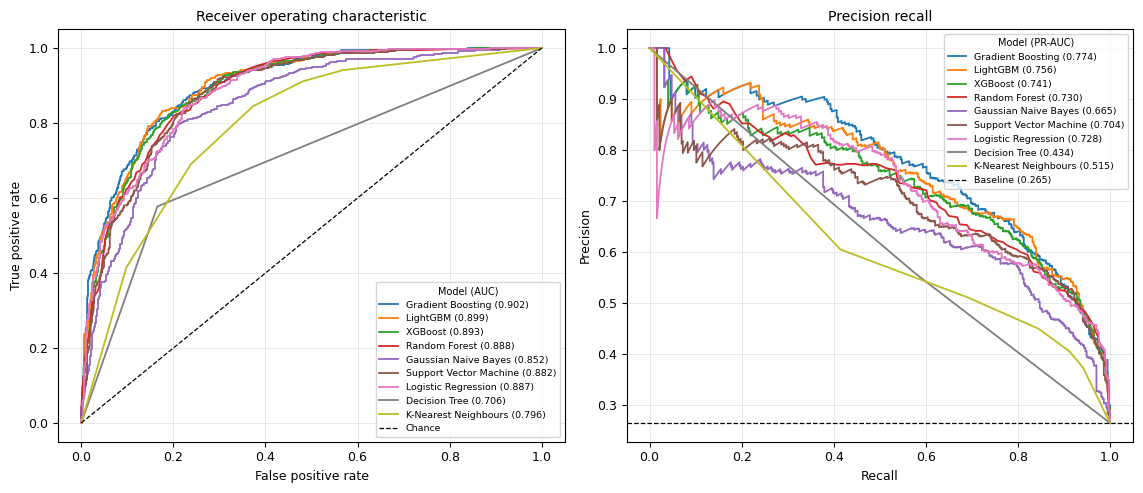

In [38]:
# --------------------------------------------------------------------------- #
# Figure 7. ROC and precision recall curves
# --------------------------------------------------------------------------- #
palette = plt.cm.tab10(np.linspace(0, 1, 10))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))

ax = axes[0]
for k, name in enumerate(order_desc):
    fpr, tpr, _ = roc_curve(y_hold, holdout_proba[name])
    ax.plot(fpr, tpr, linewidth=1.3, color=palette[k],
            label=f"{name} ({holdout_table.loc[name, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.9, label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Receiver operating characteristic", fontsize=10)
ax.legend(fontsize=6.8, loc="lower right", title="Model (AUC)", title_fontsize=7)

ax = axes[1]
for k, name in enumerate(order_desc):
    prec, rec, _ = precision_recall_curve(y_hold, holdout_proba[name])
    ax.plot(rec, prec, linewidth=1.3, color=palette[k],
            label=f"{name} ({holdout_table.loc[name, 'pr_auc']:.3f})")
ax.axhline(prevalence, color="k", linestyle="--", linewidth=0.9,
           label=f"Baseline ({prevalence:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision recall", fontsize=10)
ax.legend(fontsize=6.8, loc="upper right", title="Model (PR-AUC)", title_fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figure7_roc_pr_curves.png"), dpi=300, bbox_inches="tight")
plt.show()


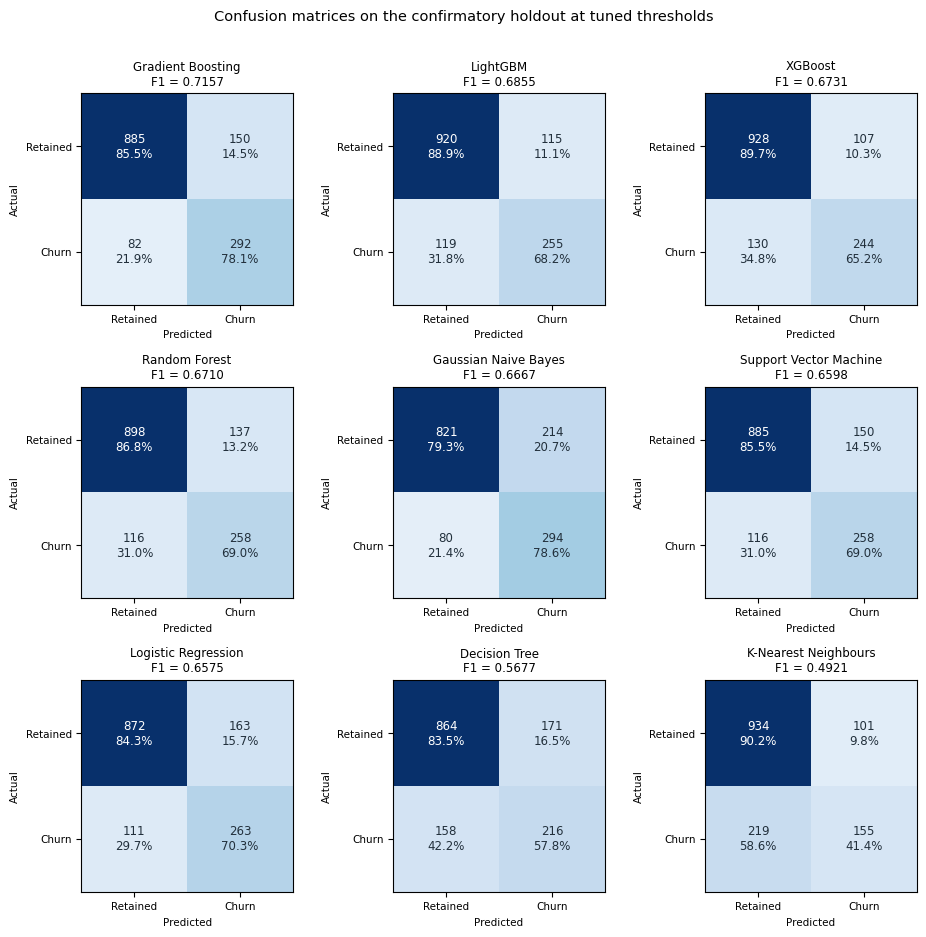


LightGBM:  TP 255   FN 119 (31.8% of churners missed)   FP 115   TN 920   threshold 0.480


In [39]:
# --------------------------------------------------------------------------- #
# Figure 8. Confusion matrices at tuned thresholds
# --------------------------------------------------------------------------- #
fig, axes = plt.subplots(3, 3, figsize=(9.5, 9.5))
for ax, name in zip(axes.ravel(), order_desc):
    cm = confusion_matrix(y_hold, (holdout_proba[name] >= holdout_thr[name]).astype(int))
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.grid(False)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cm[r, c]}\n{cm[r, c] / cm[r].sum() * 100:.1f}%",
                    ha="center", va="center", fontsize=8.5,
                    color="white" if cm[r, c] > cm.max() * 0.55 else "#22303c")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Retained", "Churn"], fontsize=7.5)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Retained", "Churn"], fontsize=7.5)
    ax.set_xlabel("Predicted", fontsize=7.5)
    ax.set_ylabel("Actual", fontsize=7.5)
    ax.set_title(f"{name}\nF1 = {holdout_table.loc[name, 'f1']:.4f}", fontsize=8.5)

fig.suptitle("Confusion matrices on the confirmatory holdout at tuned thresholds", fontsize=10.5)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(os.path.join(OUT_DIR, "figure8_confusion_matrices.png"), dpi=300, bbox_inches="tight")
plt.show()

sel = globals().get("best_model_name", order_desc[0])
tn, fp, fn, tp = confusion_matrix(
    y_hold, (holdout_proba[sel] >= holdout_thr[sel]).astype(int)).ravel()
print(f"\n{sel}:  TP {tp}   FN {fn} ({fn / (tp + fn) * 100:.1f}% of churners missed)"
      f"   FP {fp}   TN {tn}   threshold {holdout_thr[sel]:.3f}")


In [14]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import os

# Reads the fold-level results already saved to disk by cell 26 — 
# does not require re-running the benchmark or touching fold_store in memory.
folds_df = pd.read_csv(os.path.join(OUT_DIR, f"folds_{FINAL_TREATMENT}.csv"))

# Reconstruct a model -> array-of-fold-scores dict from the saved CSV
fold_dict = {model: folds_df.loc[folds_df["model"] == model, "f1"].values
             for model in folds_df["model"].unique()}

best_model_name = max(fold_dict, key=lambda m: np.mean(fold_dict[m]))
base = np.array(fold_dict[best_model_name])

rows = []
for name, arr in fold_dict.items():
    if name == best_model_name:
        continue
    arr = np.array(arr)
    diff = base - arr
    n = len(diff)

    try:
        _, p = wilcoxon(base, arr)
    except ValueError:
        p = 1.0

    abs_diff = np.abs(diff)
    ranks = pd.Series(abs_diff).rank().values
    w_pos = ranks[diff > 0].sum()
    w_neg = ranks[diff < 0].sum()
    total = n * (n + 1) / 2
    rank_biserial_r = (w_pos - w_neg) / total if total > 0 else 0.0

    rows.append({
        "comparison": f"{best_model_name} vs {name}",
        "mean_f1_diff": float(diff.mean()),
        "wilcoxon_p_raw": float(p),
        "effect_size_dz": float(diff.mean() / (diff.std() + 1e-12)),
        "effect_size_rank_biserial_r": float(rank_biserial_r),
    })

table6b = pd.DataFrame(rows).sort_values("wilcoxon_p_raw").reset_index(drop=True)
m = len(table6b)
table6b["wilcoxon_p_holm"] = np.minimum(
    1.0, np.maximum.accumulate(table6b["wilcoxon_p_raw"].values * (m - np.arange(m)))
)
table6b = table6b.round(4)
table6b.to_csv(os.path.join(OUT_DIR, "table6b_rank_biserial.csv"), index=False)
table6b

,comparison,mean_f1_diff,wilcoxon_p_raw,effect_size_dz,effect_size_rank_biserial_r,wilcoxon_p_holm
0,LightGBM vs Decision Tree,0.0697,0.0000,4.8426,1.0000,0.0000
1,LightGBM vs Gaussian Naive Bayes,0.0521,0.0000,4.0795,1.0000,0.0000
2,LightGBM vs K-Nearest Neighbours,0.1866,0.0000,4.7002,1.0000,0.0000
3,LightGBM vs Support Vector Machine,0.0362,0.0000,2.2744,1.0000,0.0000
4,LightGBM vs Random Forest,0.0267,0.0000,1.7892,1.0000,0.0000
5,LightGBM vs Logistic Regression,0.0177,0.0000,1.3339,0.9200,0.0000
6,LightGBM vs Gradient Boosting,0.0106,0.0005,0.8928,0.7538,0.0010
7,LightGBM vs XGBoost,0.0075,0.0038,0.6898,0.6431,0.0038
